## Imports


In [1]:
import nltk.downloader

nltk.downloader.download('punkt')
nltk.downloader.download('punkt_tab')
nltk.downloader.download('stopwords')

import nltk
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel, LsiModel, TfidfModel
from gensim.models.coherencemodel import CoherenceModel


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Load Data and Preprocessing

In [2]:
df = pd.read_csv('/content/bbc_news.csv')
raw_text = df['title'].fillna('') + ' ' + df['description'].fillna('')


en_stopwords = set(stopwords.words('english')).union(
    {'said', 'says', 'say', 'year', 'years', 'new', 'also', 'mr'}
)
ps = PorterStemmer()


def clean_and_tokenize(text):
  # Lowercase and remove punctuation/special characters
  clean_str = re.sub(r'[^\w\s]', '', str(text).lower())
  # Tokenize & remove stop words
  tokens = [
      word
      for word in word_tokenize(clean_str)
      if word not in en_stopwords and len(word) > 2
  ]
  # Stemming
  stemmed_tokens = [ps.stem(token) for token in tokens]
  return stemmed_tokens


articles = raw_text.apply(clean_and_tokenize)

## Vectorization (BoW & TF-IDF)

In [3]:
# Create Dictionary of unique tokens
dictionary = corpora.Dictionary(articles)
# Filter extreme tokens to remove noise
dictionary.filter_extremes(no_below=3, no_above=0.85)

# Bag of Words Representation
corpus_bow = [dictionary.doc2bow(text) for text in articles]

# TF-IDF Representation
tfidf_transformer = TfidfModel(corpus_bow)
corpus_tfidf = tfidf_transformer[corpus_bow]

## For Loop across n_topics with C_v Coherence


In [4]:
min_topics = 2
max_topics = 20
topic_range = list(range(min_topics, max_topics + 1))

# Dictionary to store the coherence scores
coherence_dict = {
    'bow_lsa': {},
    'tfidf_lsa': {},
    'bow_lda': {},
    'tfidf_lda': {},
}

for k in topic_range:
  # 1. LSA with Bag of Words
  lsa_bow = LsiModel(
      corpus=corpus_bow, num_topics=k, id2word=dictionary, random_seed=42
  )
  cm_lsa_bow = CoherenceModel(
      model=lsa_bow, texts=articles, dictionary=dictionary, coherence='c_v'
  )
  coherence_dict['bow_lsa'][k] = round(float(cm_lsa_bow.get_coherence()), 4)

  # 2. LSA with TF-IDF
  lsa_tfidf = LsiModel(
      corpus=corpus_tfidf, num_topics=k, id2word=dictionary, random_seed=42
  )
  cm_lsa_tfidf = CoherenceModel(
      model=lsa_tfidf, texts=articles, dictionary=dictionary, coherence='c_v'
  )
  coherence_dict['tfidf_lsa'][k] = round(
      float(cm_lsa_tfidf.get_coherence()), 4
  )

  # 3. LDA with Bag of Words
  lda_bow = LdaModel(
      corpus=corpus_bow,
      num_topics=k,
      id2word=dictionary,
      random_state=42,
      passes=10,
  )
  cm_lda_bow = CoherenceModel(
      model=lda_bow, texts=articles, dictionary=dictionary, coherence='c_v'
  )
  coherence_dict['bow_lda'][k] = round(float(cm_lda_bow.get_coherence()), 4)

  # 4. LDA with TF-IDF
  lda_tfidf = LdaModel(
      corpus=corpus_tfidf,
      num_topics=k,
      id2word=dictionary,
      random_state=42,
      passes=10,
  )
  cm_lda_tfidf = CoherenceModel(
      model=lda_tfidf, texts=articles, dictionary=dictionary, coherence='c_v'
  )
  coherence_dict['tfidf_lda'][k] = round(
      float(cm_lda_tfidf.get_coherence()), 4
  )

# Extract optimal n_topics for each model configuration
best_n_topics = {
    model: max(scores, key=scores.get) for model, scores in coherence_dict.items()
}

print('=== Coherence Dictionary (C_v) ===')
print(coherence_dict)
print('\n=== Best n_topics per Model ===')
for m, k in best_n_topics.items():
  print(f'{m}: Best k = {k} (Coherence C_v = {coherence_dict[m][k]})')


=== Coherence Dictionary (C_v) ===
{'bow_lsa': {2: 0.5489, 3: 0.4966, 4: 0.4136, 5: 0.4704, 6: 0.3699, 7: 0.352, 8: 0.391, 9: 0.3489, 10: 0.3902, 11: 0.3693, 12: 0.369, 13: 0.3524, 14: 0.3381, 15: 0.3908, 16: 0.3599, 17: 0.3613, 18: 0.3655, 19: 0.3453, 20: 0.3596}, 'tfidf_lsa': {2: 0.3667, 3: 0.3716, 4: 0.4658, 5: 0.359, 6: 0.3301, 7: 0.3506, 8: 0.3914, 9: 0.332, 10: 0.3493, 11: 0.4038, 12: 0.4102, 13: 0.4035, 14: 0.3803, 15: 0.372, 16: 0.3917, 17: 0.3881, 18: 0.4333, 19: 0.4105, 20: 0.4246}, 'bow_lda': {2: 0.3591, 3: 0.4276, 4: 0.3735, 5: 0.4048, 6: 0.379, 7: 0.4199, 8: 0.4353, 9: 0.4364, 10: 0.4292, 11: 0.4578, 12: 0.4361, 13: 0.4207, 14: 0.419, 15: 0.4251, 16: 0.4462, 17: 0.4388, 18: 0.4381, 19: 0.4404, 20: 0.4471}, 'tfidf_lda': {2: 0.3966, 3: 0.399, 4: 0.424, 5: 0.4794, 6: 0.4817, 7: 0.4802, 8: 0.4914, 9: 0.4827, 10: 0.4885, 11: 0.4825, 12: 0.4853, 13: 0.4935, 14: 0.4962, 15: 0.4825, 16: 0.4908, 17: 0.5094, 18: 0.507, 19: 0.519, 20: 0.5137}}

=== Best n_topics per Model ===
bow_lsa

## Comparison Graph & Bar Chart

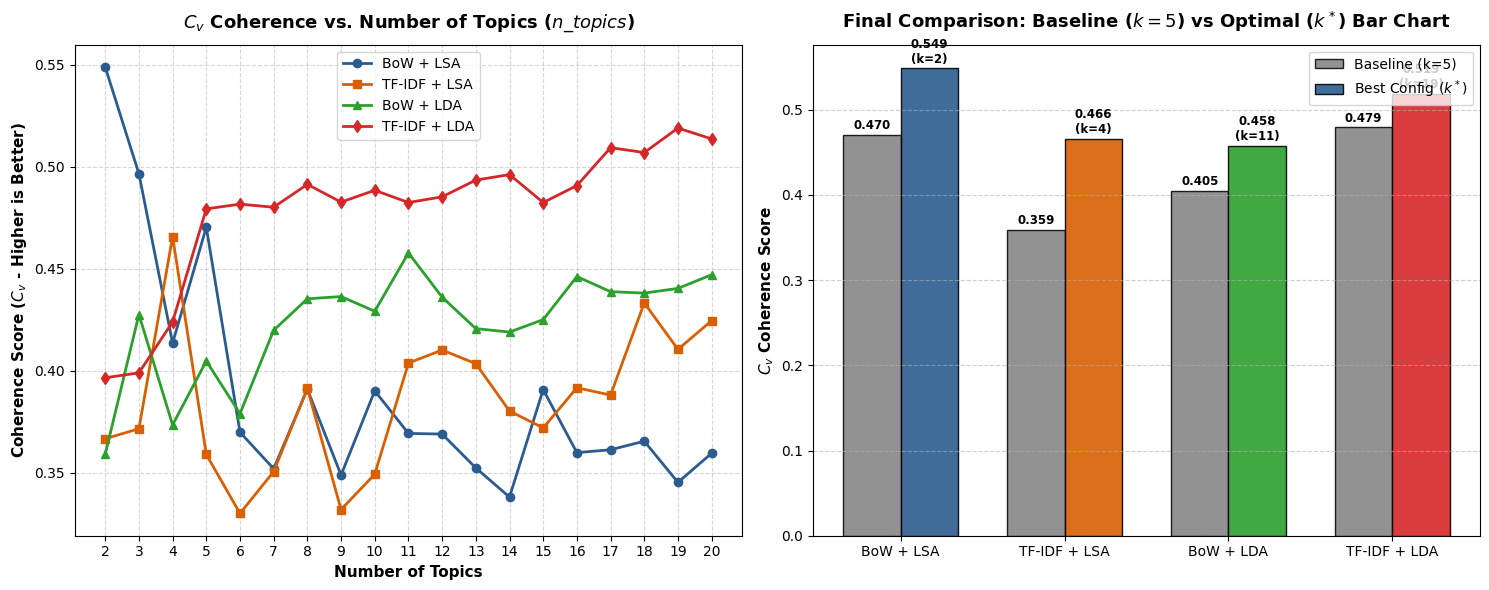

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Line Graph of C_v Coherence vs n_topics
ax1.plot(
    topic_range,
    [coherence_dict['bow_lsa'][k] for k in topic_range],
    marker='o',
    lw=2,
    color='#2b5c8f',
    label='BoW + LSA',
)
ax1.plot(
    topic_range,
    [coherence_dict['tfidf_lsa'][k] for k in topic_range],
    marker='s',
    lw=2,
    color='#d95f02',
    label='TF-IDF + LSA',
)
ax1.plot(
    topic_range,
    [coherence_dict['bow_lda'][k] for k in topic_range],
    marker='^',
    lw=2,
    color='#2ca02c',
    label='BoW + LDA',
)
ax1.plot(
    topic_range,
    [coherence_dict['tfidf_lda'][k] for k in topic_range],
    marker='d',
    lw=2,
    color='#d62728',
    label='TF-IDF + LDA',
)

ax1.set_title(
    r'$C_v$ Coherence vs. Number of Topics ($n\_topics$)',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
ax1.set_xlabel('Number of Topics', fontsize=11, fontweight='bold')
ax1.set_ylabel(
    r'Coherence Score ($C_v$ - Higher is Better)',
    fontsize=11,
    fontweight='bold',
)
ax1.set_xticks(topic_range)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='best', frameon=True)

# Plot 2: Bar Chart (Baseline vs Best Config)
labels = ['BoW + LSA', 'TF-IDF + LSA', 'BoW + LDA', 'TF-IDF + LDA']
models_keys = ['bow_lsa', 'tfidf_lsa', 'bow_lda', 'tfidf_lda']
bar_colors = ['#2b5c8f', '#d95f02', '#2ca02c', '#d62728']

baseline_k = 5
k5_scores = [coherence_dict[m][baseline_k] for m in models_keys]
best_scores = [coherence_dict[m][best_n_topics[m]] for m in models_keys]

x = np.arange(len(labels))
width = 0.35

b1 = ax2.bar(
    x - width / 2,
    k5_scores,
    width,
    label=f'Baseline (k={baseline_k})',
    color='#7f7f7f',
    alpha=0.85,
    edgecolor='black',
)
b2 = ax2.bar(
    x + width / 2,
    best_scores,
    width,
    label='Best Config ($k^*$)',
    color=bar_colors,
    alpha=0.9,
    edgecolor='black',
)

ax2.set_title(
    r'Final Comparison: Baseline ($k=5$) vs Optimal ($k^*$) Bar Chart',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
ax2.set_ylabel(r'$C_v$ Coherence Score', fontsize=11, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=10)
ax2.grid(axis='y', linestyle='--', alpha=0.6)
ax2.legend(loc='upper right', frameon=True)

# Annotate bars
for bar in b1:
  y = bar.get_height()
  ax2.annotate(
      f'{y:.3f}',
      xy=(bar.get_x() + bar.get_width() / 2, y),
      xytext=(0, 4),
      textcoords='offset points',
      ha='center',
      fontsize=8.5,
      fontweight='bold',
  )

for idx, bar in enumerate(b2):
  y = bar.get_height()
  k_val = best_n_topics[models_keys[idx]]
  ax2.annotate(
      f'{y:.3f}\n(k={k_val})',
      xy=(bar.get_x() + bar.get_width() / 2, y),
      xytext=(0, 4),
      textcoords='offset points',
      ha='center',
      fontsize=8.5,
      fontweight='bold',
  )

plt.tight_layout()
plt.show()